In [4]:
from google.colab import files
uploaded = files.upload()

Saving parkinsons+telemonitoring.zip to parkinsons+telemonitoring.zip


In [5]:
import zipfile
import os

zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files inside data folder:", os.listdir("data"))

Files inside data folder: ['parkinsons_updrs.names', 'parkinsons_updrs.data']


In [6]:
import pandas as pd
import os

# Find CSV automatically
for root, dirs, files in os.walk("data"):
    for file in files:
        if file.endswith(".csv") or file.endswith(".data"):
            file_path = os.path.join(root, file)

print("Dataset path:", file_path)

data = pd.read_csv(file_path)
print(data.head())
print("Shape:", data.shape)

Dataset path: data/parkinsons_updrs.data
   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179       0.00994   
2     0.000025     0.00205      0.00208  ...        0.181       0.00734   
3     0.000027     0.00191      0.00264  ...        0.327       0.01106   
4     0.000020     0.00093      0.00130  ...        0.176       0.00679   

   Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPD

In [7]:
# Drop unnecessary columns if present
columns_to_drop = ['subject#', 'test_time']
data = data.drop(columns=[col for col in columns_to_drop if col in data.columns])

# Features and target
X = data.drop(['total_UPDRS'], axis=1)
y = data['total_UPDRS']

print("Features shape:", X.shape)

Features shape: (5875, 19)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
!pip install xgboost
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.8138760781659066
R2 Score: 0.9897451212369845


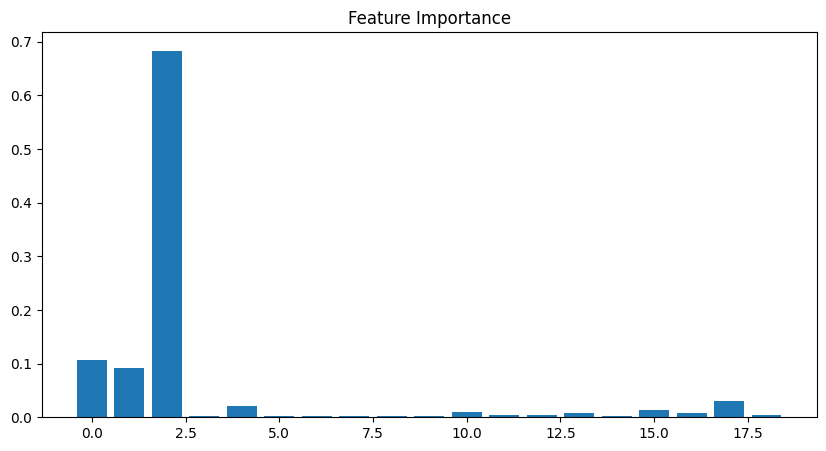

In [13]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

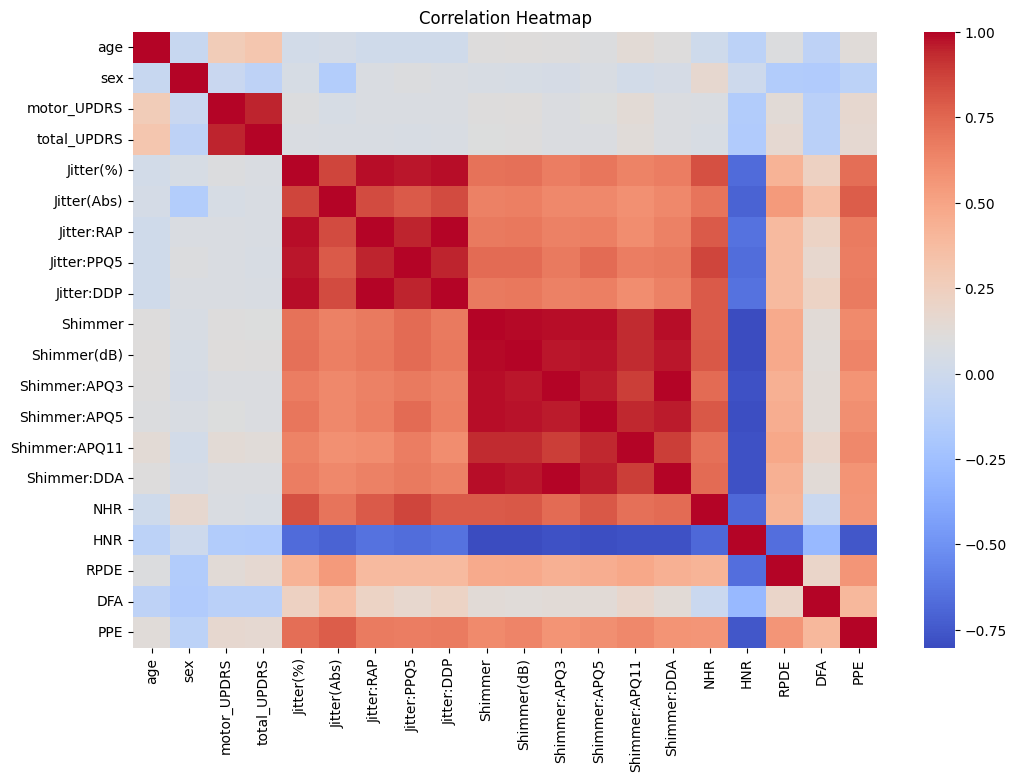

In [14]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

models = {
    "RandomForest": RandomForestRegressor(n_estimators=200),
    "XGBoost": model,  # your trained model
    "SVR": SVR()
}

from sklearn.metrics import r2_score

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(f"{name} R2:", r2_score(y_test, pred))

RandomForest R2: 0.9945720114220321
XGBoost R2: 0.9897451212369845
SVR R2: 0.9272833036368618


In [16]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("CV Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV Scores: [0.85884313 0.54927342 0.82659586 0.47806124 0.92705307]
Mean CV R2: 0.7279653477899443


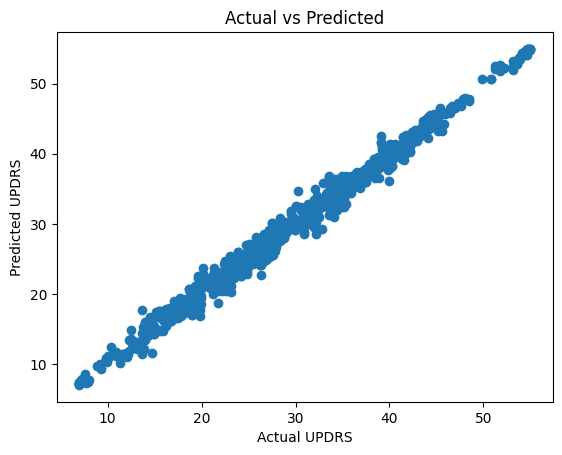

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual UPDRS")
plt.ylabel("Predicted UPDRS")
plt.title("Actual vs Predicted")
plt.show()

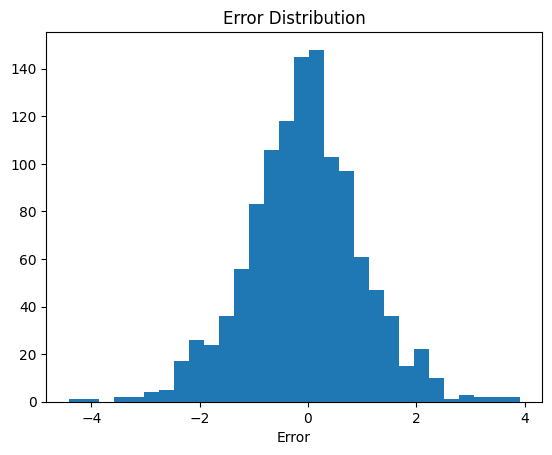

In [18]:
errors = y_test - y_pred

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.show()

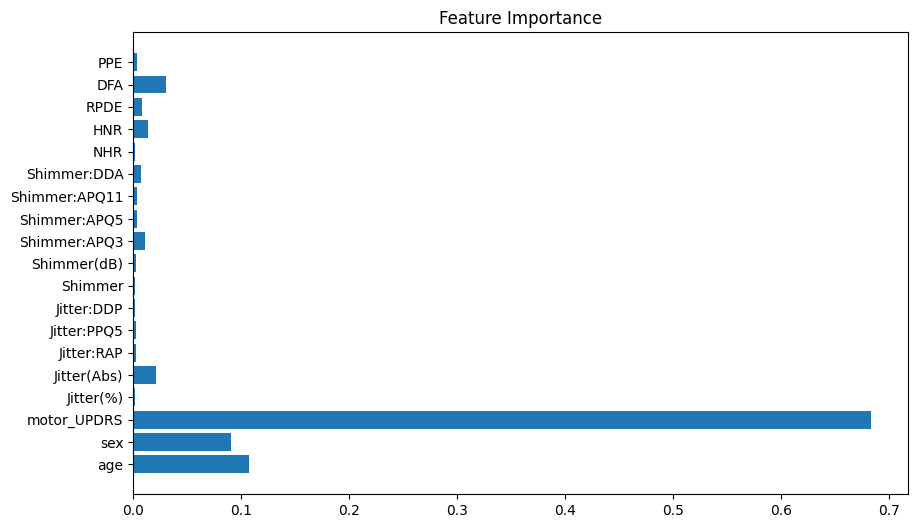

In [19]:
feature_names = X.columns

plt.figure(figsize=(10,6))
plt.barh(feature_names, model.feature_importances_)
plt.title("Feature Importance")
plt.show()

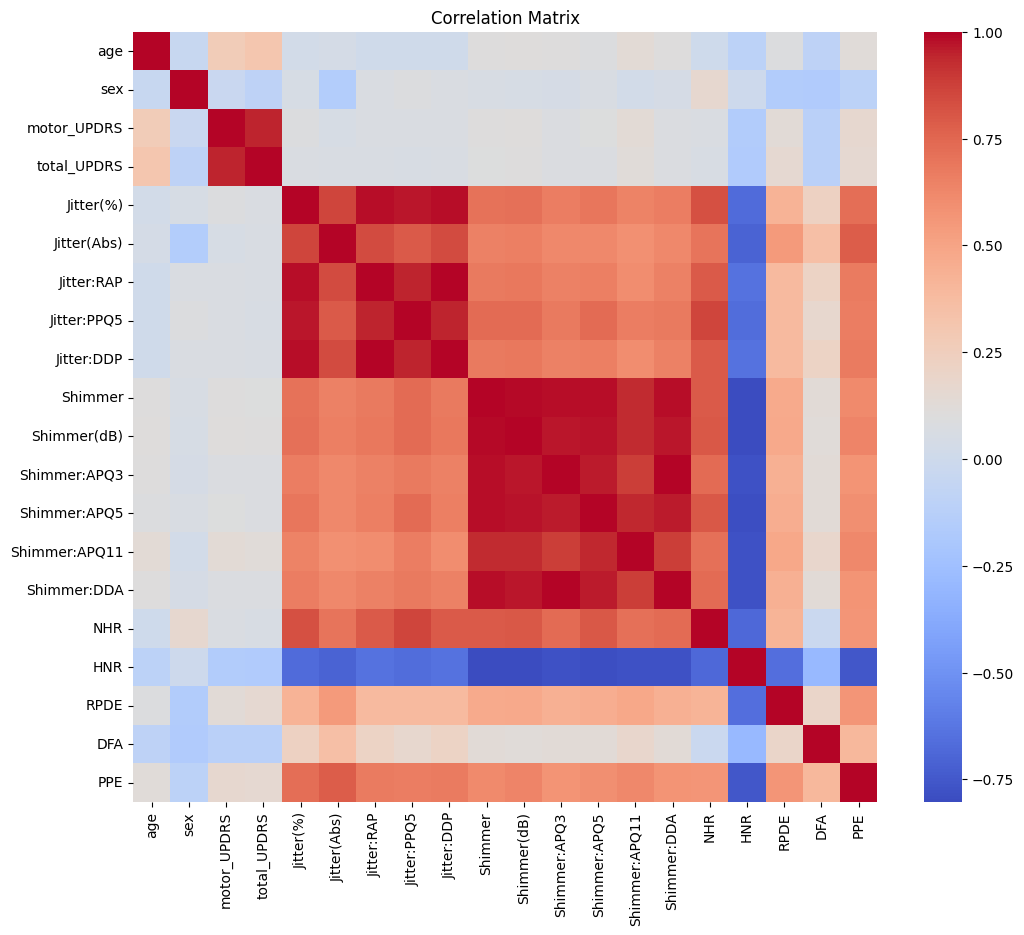

In [20]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

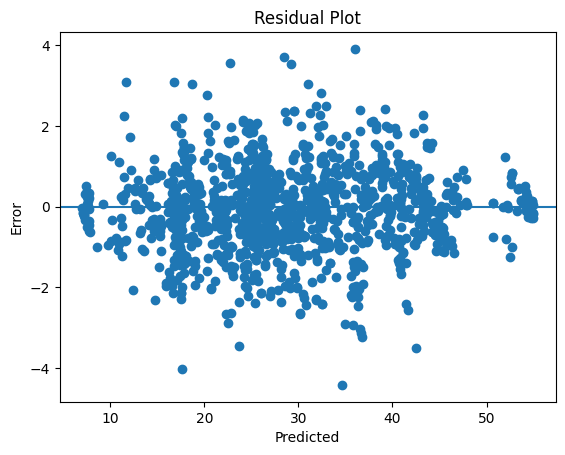

In [21]:
plt.scatter(y_pred, errors)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.show()

In [25]:
from google.colab import files
uploaded = files.upload()

Saving parkinsons+telemonitoring.zip to parkinsons+telemonitoring (1).zip


In [26]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Extracted files:", os.listdir("data"))

Extracted files: ['parkinsons_updrs.names', 'parkinsons_updrs.data']


In [28]:
for root, dirs, files in os.walk("data"):
    for file in files:
        print(os.path.join(root, file))

data/parkinsons_updrs.names
data/parkinsons_updrs.data


In [30]:
print(data.columns.tolist())

['age', 'sex', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [31]:
data.columns = data.columns.str.strip()

In [32]:
print(data.columns.tolist())

['age', 'sex', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [34]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("CV Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV Scores: [0.98945308 0.98907427 0.99002667 0.98973778 0.98993364]
Mean CV R2: 0.9896450874068199


In [35]:
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=rkf,
    scoring='r2'
)

print("Repeated CV Mean R2:", cv_scores.mean())

Repeated CV Mean R2: 0.9896739215751923


In [36]:
# REMOVE leakage feature
X = data.drop(['total_UPDRS', 'motor_UPDRS'], axis=1)
y = data['total_UPDRS']

In [37]:
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=rkf,
    scoring='r2'
)

print("Repeated CV Mean R2:", cv_scores.mean())

Repeated CV Mean R2: 0.8815332627939284
